## Environment setup
Import core analysis libraries (numpy/pandas for data, matplotlib/seaborn for plots), regex and NLTK for text preprocessing, and ensure `wordcloud` is installed for later visualizations.

In [29]:
pip install "numpy<2" --upgrade

Note: you may need to restart the kernel to use updated packages.


In [30]:
# Core analysis libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk


# Creation Of DataFrames

In [31]:
train_df = pd.read_csv('train-00000-of-00001.csv')
val_df = pd.read_csv('validation-00000-of-00001.csv')
test_df = pd.read_csv('test-00000-of-00001.csv')

# Preview Of The Raw Dataset

In [32]:
train_df.head()

,Unnamed: 0,title,text,label
0,20000,Senator Shelby starts to break banking nominee...,WASHINGTON (Reuters) - Senate Banking Committe...,1
1,20001,"Trump says he will visit Japan, South Korea, C...",ABOARD AIR FORCE ONE (Reuters) - U.S. Presiden...,1
2,20002,ILLEGAL ALIEN ARRESTED FOR SHOOTING Teen Girlf...,Since when did future Democrat voters take pre...,0
3,20003,Denver Police Officer Literally Tells Protest...,Amidst protests all around the country against...,0
4,20004,Post-election conundrum awaits Germany's Merkel,"BERLIN (Reuters) - Barring an upset, the main...",1


In [33]:
val_df.head()

,Unnamed: 0,title,text,label
0,0,Trump says to spend extra day in Philippines d...,WASHINGTON (Reuters) - President Donald Trump ...,1
1,1,Fire in Bangladesh textile factory kills six,DHAKA (Reuters) - A fire in a textile factory ...,1
2,2,Myanmar army drops charges against six journal...,YANGON (Reuters) - Myanmar s military on Frida...,1
3,3,Mentally-Ill Mother Shoots Sleeping Five-Year...,The warning signs were everywhere.Forty-one-ye...,0
4,4,No formal U.S. delegation to Castro memorial: ...,WASHINGTON (Reuters) - The United States will ...,1


In [34]:
test_df.head()

,Unnamed: 0,title,text,label
0,0,FORMER U.S. ATTORNEY: “It’s VERY Clear Intel C...,JOE DIGENOVA has been around D.C for decades a...,0
1,1,Rick Santorum Advises President To Quit Tweet...,"In a recent interview with CNN, former senator...",0
2,2,Stephen Colbert Explains The Horrifying Futur...,"With only three clowns left in GOP clown car, ...",0
3,3,Nepal votes in final round of polls at the end...,KATHMANDU (Reuters) - Nepalis began voting in ...,1
4,4,"More Americans think wealthy, not middle class...",WASHINGTON (Reuters) - Americans are more like...,1


## Modeling libraries
Import scikit-learn components used later for vectorization (TF–IDF), model training (Naïve Bayes, Linear SVM with calibration), and evaluation (accuracy/precision/recall/F1, confusion matrices, ROC, and PR curves).

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV # For SVM probabilities
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_curve, auc, precision_recall_curve)

In [37]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/amritbhattarai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/amritbhattarai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/amritbhattarai/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/amritbhattarai/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Removing Unnecesary Columns

In [38]:
train_df = train_df.drop(columns=['Unnamed: 0'])

In [39]:
train_df.head()

,title,text,label
0,Senator Shelby starts to break banking nominee...,WASHINGTON (Reuters) - Senate Banking Committe...,1
1,"Trump says he will visit Japan, South Korea, C...",ABOARD AIR FORCE ONE (Reuters) - U.S. Presiden...,1
2,ILLEGAL ALIEN ARRESTED FOR SHOOTING Teen Girlf...,Since when did future Democrat voters take pre...,0
3,Denver Police Officer Literally Tells Protest...,Amidst protests all around the country against...,0
4,Post-election conundrum awaits Germany's Merkel,"BERLIN (Reuters) - Barring an upset, the main...",1


In [40]:
val_df = val_df.drop(columns=['Unnamed: 0'])

In [41]:
val_df.head()

,title,text,label
0,Trump says to spend extra day in Philippines d...,WASHINGTON (Reuters) - President Donald Trump ...,1
1,Fire in Bangladesh textile factory kills six,DHAKA (Reuters) - A fire in a textile factory ...,1
2,Myanmar army drops charges against six journal...,YANGON (Reuters) - Myanmar s military on Frida...,1
3,Mentally-Ill Mother Shoots Sleeping Five-Year...,The warning signs were everywhere.Forty-one-ye...,0
4,No formal U.S. delegation to Castro memorial: ...,WASHINGTON (Reuters) - The United States will ...,1


In [42]:
test_df = test_df.drop(columns=['Unnamed: 0'])

In [43]:
test_df.head()

,title,text,label
0,FORMER U.S. ATTORNEY: “It’s VERY Clear Intel C...,JOE DIGENOVA has been around D.C for decades a...,0
1,Rick Santorum Advises President To Quit Tweet...,"In a recent interview with CNN, former senator...",0
2,Stephen Colbert Explains The Horrifying Futur...,"With only three clowns left in GOP clown car, ...",0
3,Nepal votes in final round of polls at the end...,KATHMANDU (Reuters) - Nepalis began voting in ...,1
4,"More Americans think wealthy, not middle class...",WASHINGTON (Reuters) - Americans are more like...,1


# Combining Title Text With Body Text
We merge each article's title and body into a single `full_text` field (filling missing parts with empty strings) to give downstream preprocessing and models the complete context.

In [44]:
# Combine title and body; fill missing pieces to avoid NaNs then trim extra spaces
train_df['full_text'] = (train_df['title'].fillna('') + ' ' + train_df['text'].fillna('')).str.strip()
val_df['full_text'] = (val_df['title'].fillna('') + ' ' + val_df['text'].fillna('')).str.strip()
test_df['full_text'] = (test_df['title'].fillna('') + ' ' + test_df['text'].fillna('')).str.strip()

## Train, Validation and Test Shape

In [45]:
print(f"Training Set Shape: {train_df.shape}")
print(f"Validation Set Shape: {val_df.shape}")
print(f"Test Set Shape: {test_df.shape}")

Training Set Shape: (24353, 4)
Validation Set Shape: (8117, 4)
Test Set Shape: (8117, 4)


In [46]:
train_df

,title,text,label,full_text
0,Senator Shelby starts to break banking nominee...,WASHINGTON (Reuters) - Senate Banking Committe...,1,Senator Shelby starts to break banking nominee...
1,"Trump says he will visit Japan, South Korea, C...",ABOARD AIR FORCE ONE (Reuters) - U.S. Presiden...,1,"Trump says he will visit Japan, South Korea, C..."
2,ILLEGAL ALIEN ARRESTED FOR SHOOTING Teen Girlf...,Since when did future Democrat voters take pre...,0,ILLEGAL ALIEN ARRESTED FOR SHOOTING Teen Girlf...
3,Denver Police Officer Literally Tells Protest...,Amidst protests all around the country against...,0,Denver Police Officer Literally Tells Proteste...
4,Post-election conundrum awaits Germany's Merkel,"BERLIN (Reuters) - Barring an upset, the main...",1,Post-election conundrum awaits Germany's Merke...
...,...,...,...,...
24348,BREAKING: Secret GOP Polls Show Trump In TOTA...,In the week since Donald Trump s complete coll...,0,BREAKING: Secret GOP Polls Show Trump In TOTAL...
24349,BREAKING NEWS: PRESIDENT TRUMP SPEAKS Out On #...,"To his credit, President Donald Trump almost i...",0,BREAKING NEWS: PRESIDENT TRUMP SPEAKS Out On #...
24350,Not-At-All-Racist Sheriff Amazingly Compares ...,In a display of Olympic-level mental gymnastic...,0,Not-At-All-Racist Sheriff Amazingly Compares T...
24351,Trump Is Crushing An Int’l Tradition That Eve...,"The whole world is talking about Donald Trump,...",0,Trump Is Crushing An Int’l Tradition That Even...


In [47]:
val_df

,title,text,label,full_text
0,Trump says to spend extra day in Philippines d...,WASHINGTON (Reuters) - President Donald Trump ...,1,Trump says to spend extra day in Philippines d...
1,Fire in Bangladesh textile factory kills six,DHAKA (Reuters) - A fire in a textile factory ...,1,Fire in Bangladesh textile factory kills six D...
2,Myanmar army drops charges against six journal...,YANGON (Reuters) - Myanmar s military on Frida...,1,Myanmar army drops charges against six journal...
3,Mentally-Ill Mother Shoots Sleeping Five-Year...,The warning signs were everywhere.Forty-one-ye...,0,Mentally-Ill Mother Shoots Sleeping Five-Year-...
4,No formal U.S. delegation to Castro memorial: ...,WASHINGTON (Reuters) - The United States will ...,1,No formal U.S. delegation to Castro memorial: ...
...,...,...,...,...
8112,Boiler Room #92 – The (Hollywood) Hills Have Eyes,Tune in to the Alternate Current Radio Network...,0,Boiler Room #92 – The (Hollywood) Hills Have E...
8113,Putin: restriction on Russian media is attack ...,"DANANG, Vietnam (Reuters) - Russian President ...",1,Putin: restriction on Russian media is attack ...
8114,REVENGE ATTACK ON MUSLIMS: VAN PLOWS INTO CROW...,A REVENGE ATTACK in London is the scene again ...,0,REVENGE ATTACK ON MUSLIMS: VAN PLOWS INTO CROW...
8115,This Mainstream News Organization Thinks Trum...,We have always known that the Republican Party...,0,This Mainstream News Organization Thinks Trump...


In [48]:
test_df

,title,text,label,full_text
0,FORMER U.S. ATTORNEY: “It’s VERY Clear Intel C...,JOE DIGENOVA has been around D.C for decades a...,0,FORMER U.S. ATTORNEY: “It’s VERY Clear Intel C...
1,Rick Santorum Advises President To Quit Tweet...,"In a recent interview with CNN, former senator...",0,Rick Santorum Advises President To Quit Tweeti...
2,Stephen Colbert Explains The Horrifying Futur...,"With only three clowns left in GOP clown car, ...",0,Stephen Colbert Explains The Horrifying Future...
3,Nepal votes in final round of polls at the end...,KATHMANDU (Reuters) - Nepalis began voting in ...,1,Nepal votes in final round of polls at the end...
4,"More Americans think wealthy, not middle class...",WASHINGTON (Reuters) - Americans are more like...,1,"More Americans think wealthy, not middle class..."
...,...,...,...,...
8112,Opposition leader says Brexit must not be used...,"BRUSSELS (Reuters) - Jeremy Corbyn, leader of ...",1,Opposition leader says Brexit must not be used...
8113,‘Pro-Life’ Scott Walker Just Signed Two Bills...,Republicans always talk a big game about being...,0,‘Pro-Life’ Scott Walker Just Signed Two Bills ...
8114,LIBERAL HUMOR? FLORIDA BAR POSTS SIGN Suggesti...,It s a federal offense to threaten a president...,0,LIBERAL HUMOR? FLORIDA BAR POSTS SIGN Suggesti...
8115,New York protesters camp out at Goldman Sachs ...,NEW YORK (Reuters) - Dozens of protesters gath...,1,New York protesters camp out at Goldman Sachs ...


# Checking Data Cleanliness

## Data cleanliness diagnostics
We profile each split (Train/Validation/Test) to confirm schema, count missing values, detect duplicates, inspect raw text lengths, and check label balance. This establishes whether further cleaning or deduplication is needed before modeling.

In [49]:

def dataset_checks(df, name):
    print(f"\n=== {name} ===")
    print(df.info())
    print("\nMissing values per column:\n", df.isna().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    # Text length on full_text (before cleaning)
    if 'full_text' in df:
        lengths = df['full_text'].fillna('').str.len()
        print("\nText length stats:\n", lengths.describe(percentiles=[0.25,0.5,0.75,0.9,0.95]))
        print("Empty full_text rows:", (lengths == 0).sum())
    # Label balance
    if 'label' in df:
        counts = df['label'].value_counts().sort_index()
        print("\nLabel counts:\n", counts)
        print("\nLabel percentages (%):\n", (counts / counts.sum() * 100).round(2))

for split_name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    dataset_checks(split_df, split_name)



=== Train ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24353 entries, 0 to 24352
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      24353 non-null  object
 1   text       24353 non-null  object
 2   label      24353 non-null  int64 
 3   full_text  24353 non-null  object
dtypes: int64(1), object(3)
memory usage: 761.2+ KB
None

Missing values per column:
 title        0
text         0
label        0
full_text    0
dtype: int64

Duplicate rows: 0

Text length stats:
 count    24353.000000
mean      2551.209748
std       2056.823286
min         21.000000
25%       1346.000000
50%       2285.000000
75%       3196.000000
90%       4628.600000
95%       5613.800000
max      49765.000000
Name: full_text, dtype: float64
Empty full_text rows: 0

Label counts:
 label
0    11158
1    13195
Name: count, dtype: int64

Label percentages (%):
 label
0    45.82
1    54.18
Name: count, dtype: float64

=== Validation =

As there are no missing values in the dataset the dataset does not need further cleaning

## Class distribution overview
We report counts and percentages of each label per split and overall, the total number of classes, and a bar chart of counts. This documents dataset balance and supports any discussion of class imbalance handling.


Train distribution:
   label  count  percent
0      0  11158    45.82
1      1  13195    54.18

Validation distribution:
   label  count  percent
0      0   3723    45.87
1      1   4394    54.13

Test distribution:
   label  count  percent
0      0   3782    46.59
1      1   4335    53.41

Overall distribution:
   label  count  percent
0      0  18663    45.98
1      1  21924    54.02

Number of classes: 2
Classes: [0, 1]


,split,label,count,percent
0,Train,0,11158,45.82
1,Train,1,13195,54.18
2,Validation,0,3723,45.87
3,Validation,1,4394,54.13
4,Test,0,3782,46.59
5,Test,1,4335,53.41
6,Overall,0,18663,45.98
7,Overall,1,21924,54.02


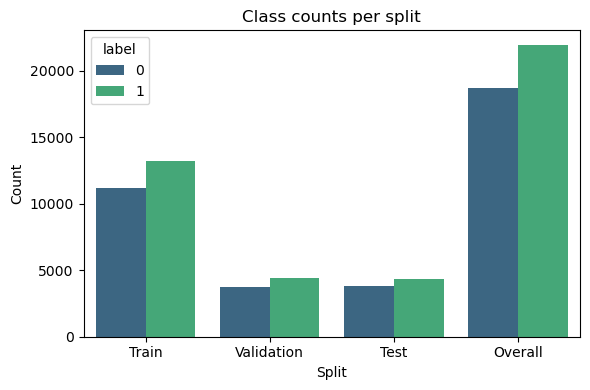

In [50]:

def summarize_distribution(df, name):
    counts = df['label'].value_counts().sort_index()
    perc = counts / counts.sum() * 100
    summary = pd.DataFrame({
        'split': name,
        'label': counts.index,
        'count': counts.values,
        'percent': perc.round(2).values
    })
    print(f"\n{name} distribution:")
    print(summary[['label','count','percent']])
    return summary

# Per split
dist_train = summarize_distribution(train_df, "Train")
dist_val   = summarize_distribution(val_df,   "Validation")
dist_test  = summarize_distribution(test_df,  "Test")

# Overall
all_df  = pd.concat([train_df, val_df, test_df], axis=0)
dist_all = summarize_distribution(all_df, "Overall")

# Number of classes (overall)
n_classes = all_df['label'].nunique()
classes   = sorted(all_df['label'].unique())
print(f"\nNumber of classes: {n_classes}")
print(f"Classes: {classes}")

# Combined table
dist_table = pd.concat([dist_train, dist_val, dist_test, dist_all], axis=0).reset_index(drop=True)
display(dist_table)

# Optional: bar chart of counts per split
plt.figure(figsize=(6,4))
sns.barplot(data=dist_table, x='split', y='count', hue='label', palette='viridis')
plt.title('Class counts per split')
plt.ylabel('Count'); plt.xlabel('Split')
plt.tight_layout()
plt.show()
# ...existing code...

# Text Preprocessing

## Text normalization plan
We tokenize lowercased text, remove URLs, strip non-letters/digits, drop stopwords, and lemmatize tokens so the model learns from consistent word forms while discarding noise.

In [51]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [52]:
def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 3. Remove special characters and numbers
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d', ' ', text)
    
    # 4. Tokenization
    tokens = word_tokenize(text)
    
    # 5. Remove Stopwords and 6. Lemmatization
    clean_tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    
    return ' '.join(clean_tokens)

print("Preprocessing data... (This may take a minute)")

Preprocessing data... (This may take a minute)


# Processing the given data

In [53]:
for split_df in (train_df, val_df, test_df):
    split_df['clean_text'] = split_df['full_text'].apply(preprocess_text)

# TF-IDF Vectorization

## Feature representation
We vectorize cleaned text with TF–IDF using up to 8000 features and both unigrams and bigrams, yielding sparse numeric inputs suitable for linear models.

In [54]:
tfidf_vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1,2))

X_train = tfidf_vectorizer.fit_transform(train_df['clean_text'])
X_val   = tfidf_vectorizer.transform(val_df['clean_text'])
X_test  = tfidf_vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

# Model Training

## Models fitted
We train two linear baselines: Multinomial Naïve Bayes (fast, strong on word counts) and a class-balanced Linear SVM wrapped with calibration to obtain probabilities for ROC and thresholding.

## Naives Bayes

In [55]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Linear SVM

In [56]:
svm_linear = LinearSVC(class_weight='balanced', random_state=42)
svm_model = CalibratedClassifierCV(svm_linear, cv=5)
svm_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(cla...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or 

## Evaluation helper

In [57]:
def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    print(f"\n=== {name} ===")
    print(classification_report(y, y_pred, target_names=['Fake', 'Real']))

    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()
    return y_pred, y_prob

# Evaluate on test set

## Evaluation protocol
We compute classification reports, confusion matrices, ROC curves (with AUC), and a comparative bar chart of accuracy, precision, recall, and F1 to assess model performance and class balance effects.


=== Naïve Bayes ===
              precision    recall  f1-score   support

        Fake       0.92      0.94      0.93      3782
        Real       0.95      0.93      0.94      4335

    accuracy                           0.94      8117
   macro avg       0.94      0.94      0.94      8117
weighted avg       0.94      0.94      0.94      8117



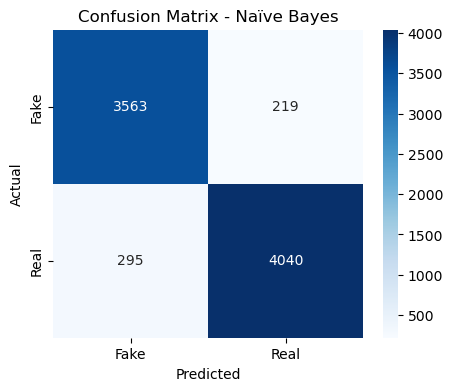


=== SVM ===
              precision    recall  f1-score   support

        Fake       0.97      0.98      0.97      3782
        Real       0.98      0.97      0.98      4335

    accuracy                           0.98      8117
   macro avg       0.98      0.98      0.98      8117
weighted avg       0.98      0.98      0.98      8117



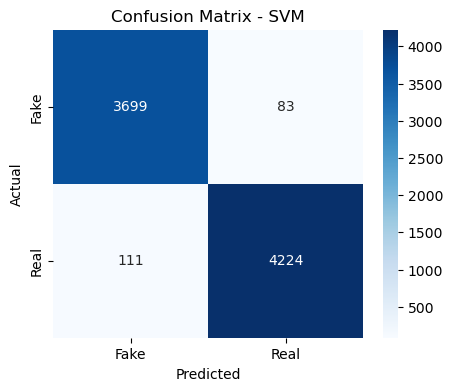

In [58]:
nb_pred,  nb_prob  = evaluate_model(nb_model,  X_test, y_test, "Naïve Bayes")
svm_pred, svm_prob = evaluate_model(svm_model, X_test, y_test, "SVM")

## Roc Curves

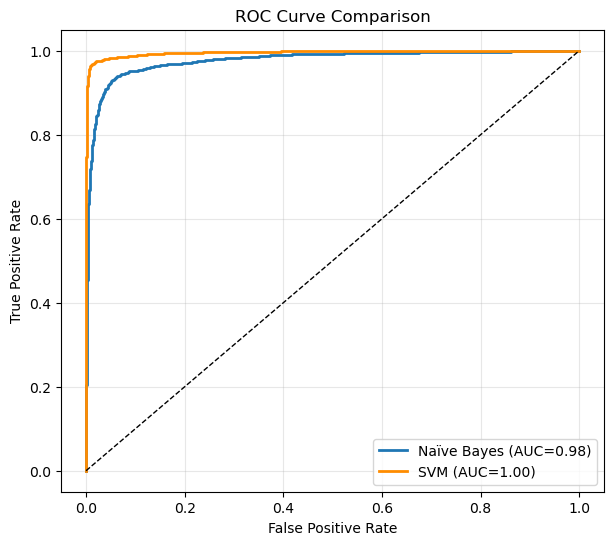

In [59]:
fpr_nb, tpr_nb, _   = roc_curve(y_test, nb_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)
roc_auc_nb  = auc(fpr_nb, tpr_nb)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(7,6))
plt.plot(fpr_nb, tpr_nb, label=f'Naïve Bayes (AUC={roc_auc_nb:.2f})', lw=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={roc_auc_svm:.2f})', lw=2, color='darkorange')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.show()

# Comparative metrics bar chart

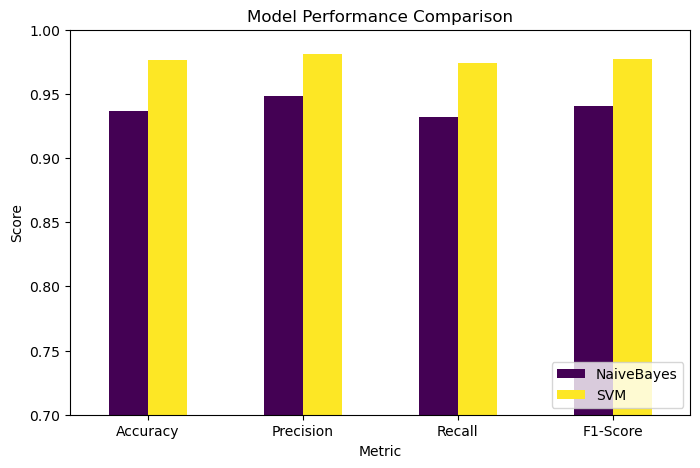

In [60]:
metrics_df = pd.DataFrame({
    'Metric':    ['Accuracy','Precision','Recall','F1-Score'],
    'NaiveBayes':[accuracy_score(y_test, nb_pred),
                  precision_score(y_test, nb_pred),
                  recall_score(y_test, nb_pred),
                  f1_score(y_test, nb_pred)],
    'SVM':       [accuracy_score(y_test, svm_pred),
                  precision_score(y_test, svm_pred),
                  recall_score(y_test, svm_pred),
                  f1_score(y_test, svm_pred)]
})
metrics_df.set_index('Metric').plot(kind='bar', figsize=(8,5), colormap='viridis')
plt.ylim(0.7, 1.0)
plt.title('Model Performance Comparison')
plt.ylabel('Score'); plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# Word Clouds Exploration

## Exploratory word clouds
Optional visualization: word clouds built from cleaned text in each split to qualitatively inspect common terms and spot potential noise or bias.

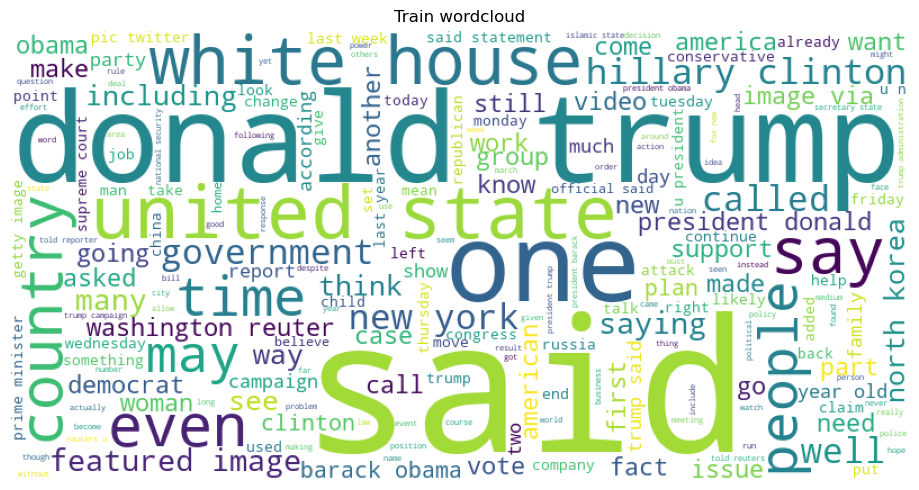

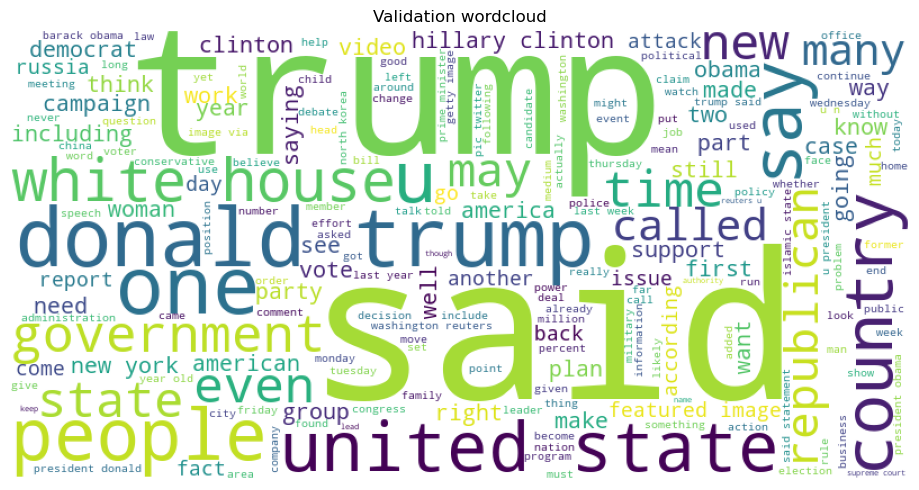

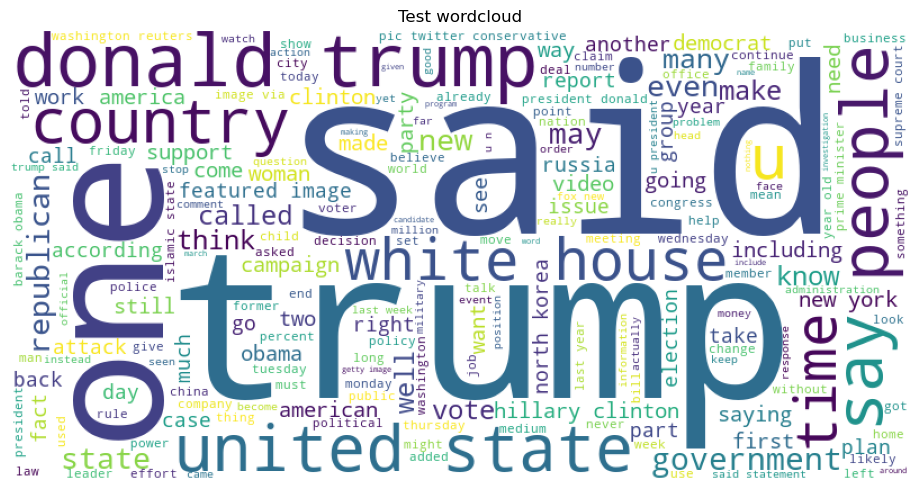

In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(texts, title):
    # Normalize input to a list of non-empty strings
    if isinstance(texts, pd.Series):
        texts = texts.astype(str).tolist()
    elif isinstance(texts, list):
        texts = [str(t) for t in texts]
    else:
        texts = [str(texts)]

    texts = [t for t in texts if isinstance(t, str) and t.strip()]
    if len(texts) == 0:
        print("No text available to plot.")
        return

    txt = " ".join(texts)
    wc = WordCloud(width=800, height=400, background_color="white").generate(txt)
    img = wc.to_image()  # PIL image avoids numpy copy kw issues on older numpy
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_wordcloud(train_df["clean_text"], "Train wordcloud")
plot_wordcloud(val_df["clean_text"], "Validation wordcloud")
plot_wordcloud(test_df["clean_text"], "Test wordcloud")

# Prediction

## Inference example
We demonstrate the end-to-end pipeline by preprocessing new text, vectorizing it with the trained TF–IDF model, and returning the predicted label with calibrated probability.

In [67]:
def predict_news(text, model):
    cleaned = preprocess_text(text)
    vec = tfidf_vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][pred]
    return ("REAL" if pred==1 else "FAKE", prob)

sample_fake = "Breaking: Cats have landed in New York and demand to speak to the alien president."
sample_real = "Central bank raises interest rates by 1.25% to curb inflation, citing resilient labor markets."

for sample in [sample_fake, sample_real]:
    label, conf = predict_news(sample, svm_model)
    print(f"Text: {sample}\nPrediction (SVM): {label} (Confidence: {conf:.2%})\n")

Text: Breaking: Cats have landed in New York and demand to speak to the alien president.
Prediction (SVM): FAKE (Confidence: 99.81%)

Text: Central bank raises interest rates by 1.25% to curb inflation, citing resilient labor markets.
Prediction (SVM): REAL (Confidence: 94.32%)



## Prediction outputs summary
- The fabricated headline (cats/aliens) is flagged as FAKE with very high confidence (~99.81%), indicating the model effectively rejects implausible content.
- The economic news headline is classified as REAL with strong confidence (~94.32%), showing the model aligns with credible, fact-like language.